# Codificação de Sinais Multimedia

## Trabalho Laboratorial 2

- 52146 - Margarida Andrade
- 52345 - Jorge Gonçalves
- 52708 - Helena Nina

In [2]:
import numpy as np
import matplotlib as plt


## Exercicio A

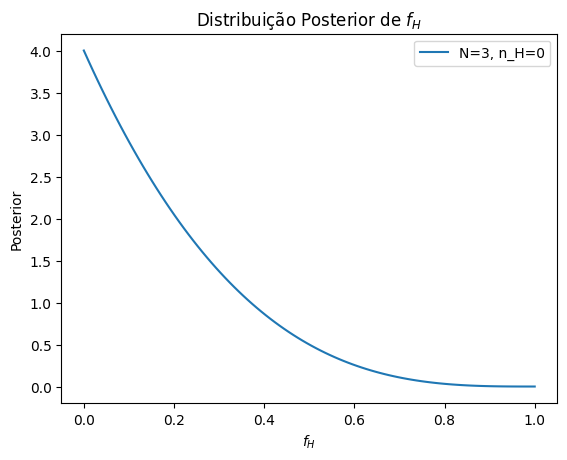

Probabilidade do próximo lançamento ser cara: 0.200


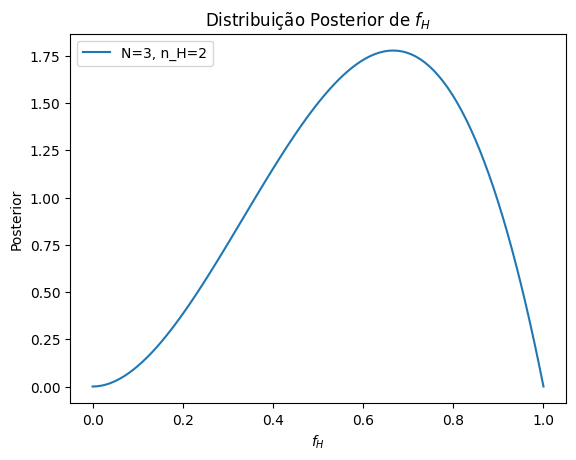

Probabilidade do próximo lançamento ser cara: 0.600


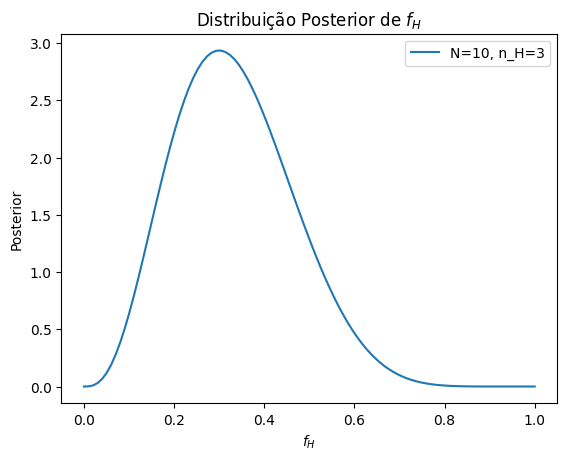

Probabilidade do próximo lançamento ser cara: 0.333


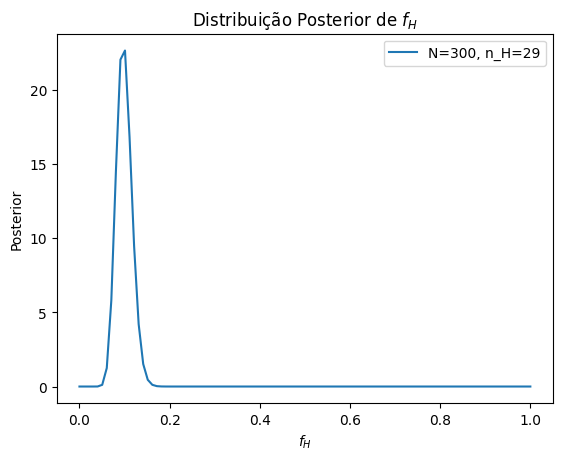

Probabilidade do próximo lançamento ser cara: 0.099


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

def plot_posterior(N, n_H):
    a = n_H + 1
    b = N - n_H + 1
    f_H = np.linspace(0, 1, 100)
    posterior = beta.pdf(f_H, a, b)
    plt.plot(f_H, posterior, label=f'N={N}, n_H={n_H}')
    plt.xlabel('$f_H$')
    plt.ylabel('Posterior')
    plt.title('Distribuição Posterior de $f_H$')
    plt.legend()
    plt.show()
    print(f'Probabilidade do próximo lançamento ser cara: {a/(a+b):.3f}')

# Exemplos do exercício
plot_posterior(3, 0)
plot_posterior(3, 2)
plot_posterior(10, 3)
plot_posterior(300, 29)

## Exercicio B
### alinea a.

In [4]:
# Prior dos algoritmos: [A, B, C]
P_algoritmo = np.array([0.40, 0.35, 0.25])

# Matriz de verosimilhança P(NC | algoritmo)
# Linhas: NC = 0,1,2,3,4 | Colunas: A,B,C
P_NC_dado_algoritmo = np.array([
    [0.05, 0.10, 0.20],
    [0.15, 0.20, 0.25],
    [0.40, 0.40, 0.30],
    [0.30, 0.20, 0.15],
    [0.10, 0.10, 0.10],
])

# Distribuição conjunta P(NC, algoritmo) = P(NC | algoritmo) * P(algoritmo)
P_conjunta = P_NC_dado_algoritmo * P_algoritmo

# Distribuição marginal dos níveis de compressão P(NC)
P_NC = P_conjunta.sum(axis=1)

# Validações dos axiomas/propriedades de probabilidade
assert np.allclose(np.sum(P_algoritmo), 1.0), 'O prior P(algoritmo) não soma 1.'
assert np.allclose(np.sum(P_NC_dado_algoritmo, axis=0), 1.0), 'Alguma coluna de P(NC|algoritmo) não soma 1.'
assert np.allclose(np.sum(P_conjunta), 1.0), 'A distribuição conjunta não soma 1.'
assert np.allclose(np.sum(P_NC), 1.0), 'A marginal P(NC) não soma 1.'

print('P_algoritmo =', P_algoritmo)
print('\nP(NC | algoritmo) =\n', P_NC_dado_algoritmo)
print('\nP_conjunta = P(NC, algoritmo) =\n', P_conjunta)
print('\nP(NC) (marginal) =', P_NC)
print('Soma de P(NC):', P_NC.sum())
print('\nValidação OK: todas as distribuições somam 1.')

P_algoritmo = [0.4  0.35 0.25]

P(NC | algoritmo) =
 [[0.05 0.1  0.2 ]
 [0.15 0.2  0.25]
 [0.4  0.4  0.3 ]
 [0.3  0.2  0.15]
 [0.1  0.1  0.1 ]]

P_conjunta = P(NC, algoritmo) =
 [[0.02   0.035  0.05  ]
 [0.06   0.07   0.0625]
 [0.16   0.14   0.075 ]
 [0.12   0.07   0.0375]
 [0.04   0.035  0.025 ]]

P(NC) (marginal) = [0.105  0.1925 0.375  0.2275 0.1   ]
Soma de P(NC): 1.0000000000000002

Validação OK: todas as distribuições somam 1.


### alinea b.

In [5]:
def classifica_algoritmo(NC):
    """
    Devolve P(algoritmo | NC) para algoritmo em [A, B, C].
    """
    if NC < 0 or NC > 4:
        raise ValueError('NC deve estar entre 0 e 4.')

    numerador = P_NC_dado_algoritmo[NC, :] * P_algoritmo
    denominador = numerador.sum()
    posterior = numerador / denominador
    return posterior

# Classificação para NC observado = 3
NC_obs = 3
posterior_nc3 = classifica_algoritmo(NC_obs)
algoritmos = np.array(['A', 'B', 'C'])
algoritmo_MAP = algoritmos[np.argmax(posterior_nc3)]

print(f'P(algoritmo | NC={NC_obs}) =')
for alg, prob in zip(algoritmos, posterior_nc3):
    print(f'  {alg}: {prob:.6f}')

print(f'\nAlgoritmo mais provável (MAP): {algoritmo_MAP}')

P(algoritmo | NC=3) =
  A: 0.527473
  B: 0.307692
  C: 0.164835

Algoritmo mais provável (MAP): A


### alinea c.

In [6]:
# -------------------------
# Alinea c) ML e MAP
# -------------------------

niveis = np.arange(P_NC_dado_algoritmo.shape[0])  # [0,1,2,3,4]
algoritmos = np.array(['A', 'B', 'C'])

# ML: NC mais verosimil para cada algoritmo (argmax em P(NC|algoritmo), por coluna)
idx_ml_por_alg = np.argmax(P_NC_dado_algoritmo, axis=0)

print('ML - nível de compressão mais verosímil para cada algoritmo:')
for i, alg in enumerate(algoritmos):
    nc_ml = niveis[idx_ml_por_alg[i]]
    prob_ml = P_NC_dado_algoritmo[nc_ml, i]
    print(f'  Algoritmo {alg}: NC* = {nc_ml} (P={prob_ml:.3f})')

# MAP: algoritmo mais provável para cada NC observado (argmax em P(algoritmo|NC), por linha)
posterior_todos_nc = P_conjunta / P_NC[:, None]
idx_map_por_nc = np.argmax(posterior_todos_nc, axis=1)

print('\nMAP - algoritmo mais provável para cada nível observado NC:')
for nc in niveis:
    alg_map = algoritmos[idx_map_por_nc[nc]]
    probs = posterior_todos_nc[nc]
    print(f'  NC={nc}: algoritmo MAP = {alg_map} | P(A|NC)={probs[0]:.3f}, P(B|NC)={probs[1]:.3f}, P(C|NC)={probs[2]:.3f}')

ML - nível de compressão mais verosímil para cada algoritmo:
  Algoritmo A: NC* = 2 (P=0.400)
  Algoritmo B: NC* = 2 (P=0.400)
  Algoritmo C: NC* = 2 (P=0.300)

MAP - algoritmo mais provável para cada nível observado NC:
  NC=0: algoritmo MAP = C | P(A|NC)=0.190, P(B|NC)=0.333, P(C|NC)=0.476
  NC=1: algoritmo MAP = B | P(A|NC)=0.312, P(B|NC)=0.364, P(C|NC)=0.325
  NC=2: algoritmo MAP = A | P(A|NC)=0.427, P(B|NC)=0.373, P(C|NC)=0.200
  NC=3: algoritmo MAP = A | P(A|NC)=0.527, P(B|NC)=0.308, P(C|NC)=0.165
  NC=4: algoritmo MAP = A | P(A|NC)=0.400, P(B|NC)=0.350, P(C|NC)=0.250


### alinea d.

In [7]:
# -------------------------
# Alinea d) E[NC|algoritmo] e Var(NC|algoritmo)
# -------------------------

# E[NC|alg] = sum_nc nc * P(NC|alg)
media_nc_por_alg = np.sum(niveis[:, None] * P_NC_dado_algoritmo, axis=0)

# E[NC^2|alg]
seg_momento_por_alg = np.sum((niveis[:, None] ** 2) * P_NC_dado_algoritmo, axis=0)

# Var(NC|alg) = E[NC^2|alg] - (E[NC|alg])^2
var_nc_por_alg = seg_momento_por_alg - media_nc_por_alg**2

print('Valor esperado e variância do nível de compressão por algoritmo:')
for i, alg in enumerate(algoritmos):
    print(f'  {alg}: E[NC|{alg}] = {media_nc_por_alg[i]:.3f}, Var(NC|{alg}) = {var_nc_por_alg[i]:.3f}')

Valor esperado e variância do nível de compressão por algoritmo:
  A: E[NC|A] = 2.250, Var(NC|A) = 0.987
  B: E[NC|B] = 2.000, Var(NC|B) = 1.200
  C: E[NC|C] = 1.700, Var(NC|C) = 1.510


### alinea e.

In [8]:
# -------------------------
# Alinea e) Estimativa empírica com 50000 amostras
# -------------------------

N = 50000
np.random.seed(42)

# 1) Gerar algoritmos segundo o prior P(algoritmo)
alg_idx = np.random.choice(3, size=N, p=P_algoritmo)  # 0->A, 1->B, 2->C

# 2) Gerar NC segundo P(NC | algoritmo) para cada amostra
NC_sim = np.empty(N, dtype=int)
for i in range(3):
    mask = (alg_idx == i)
    n_i = np.sum(mask)
    if n_i > 0:
        NC_sim[mask] = np.random.choice(5, size=n_i, p=P_NC_dado_algoritmo[:, i])

# 3) Estimar empiricamente P(algoritmo | NC=2)
mask_nc2 = (NC_sim == 2)

if np.sum(mask_nc2) == 0:
    raise RuntimeError('Nenhuma amostra com NC=2. Aumente N ou mude a seed.')

contagens_emp = np.bincount(alg_idx[mask_nc2], minlength=3)
P_emp = contagens_emp / contagens_emp.sum()

# 4) Valor teórico: P(algoritmo | NC=2)
numerador_teo = P_NC_dado_algoritmo[2, :] * P_algoritmo
denominador_teo = np.sum(numerador_teo)
P_teo = numerador_teo / denominador_teo

# 5) Comparação
erro_abs = np.abs(P_emp - P_teo)

print(f'Total de amostras: {N}')
print(f'Amostras com NC=2: {contagens_emp.sum()}')
print('\nComparação P(algoritmo | NC=2):')
for i, alg in enumerate(algoritmos):
    print(
        f'  {alg}: empírico={P_emp[i]:.6f} | teórico={P_teo[i]:.6f} | erro abs={erro_abs[i]:.6f}'
    )

print(f'\nErro absoluto médio: {erro_abs.mean():.6f}')

Total de amostras: 50000
Amostras com NC=2: 18677

Comparação P(algoritmo | NC=2):
  A: empírico=0.427745 | teórico=0.426667 | erro abs=0.001079
  B: empírico=0.370081 | teórico=0.373333 | erro abs=0.003252
  C: empírico=0.202174 | teórico=0.200000 | erro abs=0.002174

Erro absoluto médio: 0.002168


## Exercicio C
### alinea a.
#### N = 4 e N = 10

### alinea b.
#### N = 10, 210, 410, 610, 810, 1010
